In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
# import pybedtools
import intervaltree  # Or use GenomeIntervalTree from intervaltree-bio
from tqdm import tqdm
import pandas as pd
from kneed import KneeLocator
from collections import defaultdict


In [2]:
chr_colors = {
    'chr1': '#FF6B6B', 'chr2': '#4ECDC4', 'chr3': '#45B7D1', 'chr4': '#FFA07A',
    'chr5': '#92D050', 'chr6': '#D35FB7', 'chr7': '#FFC000', 'chr8': '#00B0F0',
    'chr9': '#A2D96C', 'chr10': '#C00000', 'chr11': '#7030A0', 'chr12': '#FF5733',
    'chr13': '#00AEEF', 'chr14': '#FF99CC', 'chr15': '#8FD8D8', 'chr16': '#F6546A',
    'chr17': '#468499', 'chr18': '#FFD700', 'chr19': '#088DA5', 'chr20': '#F08080',
    'chr21': '#6A5ACD', 'chr22': '#65B891', 'chr23': '#FFA500', 'chr24': '#BA55D3',
    'chr25': '#9370DB', 'chr26': '#3CB371', 'chr27': '#7B68EE', 'chr28': '#40E0D0',
    'chrX': '#FF1493',  # Distinct pink for X
    'chrY': '#14FF82'   # Dark blue for Y
}

In [3]:
dup = pd.read_csv(
    "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/genome-annotation/biser/hifiasm-041425/segdup_output_duplicateLinkRemoved.bedpe",
    sep="\t",
    header=None,
    names=["chr1", "start1", "end1", "chr2", "start2", "end2","reference","score","strand1","strand2","max_len","aln_len","cigar","optional"]
)
print(dup.shape)
# Assuming 'dup' is your DataFrame
dup = pd.concat([
    dup[['chr1', 'start1', 'end1']].rename(columns={'chr1': 'chrom', 'start1': 'start', 'end1': 'end'}),
    dup[['chr2', 'start2', 'end2']].rename(columns={'chr2': 'chrom', 'start2': 'start', 'end2': 'end'})
], ignore_index=True)

(203532, 14)


In [4]:
## Total number of basepairs 
def merge_segdup_intervals(df):
    """
    Merge overlapping or adjacent segdup hotspot intervals
    """
    merged_data = []
    
    # Group by chromosome
    for chrom, group in df.groupby('chrom'):
        # Sort by start position
        sorted_group = group.sort_values('start')
        
        if len(sorted_group) == 0:
            continue
            
        merged_intervals = []
        current_start = sorted_group.iloc[0]['start']
        current_end = sorted_group.iloc[0]['end']
        
        for i in range(1, len(sorted_group)):
            row = sorted_group.iloc[i]
            start, end = row['start'], row['end']
            
            # Check for overlap or adjacency
            if start <= current_end:
                # Overlapping or adjacent - extend current interval if needed
                current_end = max(current_end, end)
            else:
                # No overlap - save current interval and start new one
                merged_intervals.append({
                    'chrom': chrom,
                    'start': current_start,
                    'end': current_end,
                    'Length': current_end - current_start
                })
                current_start = start
                current_end = end
        
        # Don't forget the last interval
        merged_intervals.append({
            'chrom': chrom,
            'start': current_start,
            'end': current_end,
            'Length': current_end - current_start
        })
        
        merged_data.extend(merged_intervals)
    
    return pd.DataFrame(merged_data)

In [5]:
# hotspot_df = dup
# Merge the hotspot intervals
merged_segdup = merge_segdup_intervals(dup)
print(merged_segdup.shape)

(29101, 4)


In [6]:
merged_segdup["Length"].sum()

np.int64(528097744)

In [7]:
# Load genes with overlap information 
## This is calculated from calculate_segdup_geneOverlap_newHiFiAnnotation.ipynb
genes = pd.read_csv("./hifiasm_gene_segDup_overlapInfo_081726.tsv", sep="\t")
genes["Start"] = genes["Start"].astype(int)
genes["End"] = genes["End"].astype(int)
genes["overlaps_dup"] = genes["overlaps_dup"].astype(bool)
genes

,Unnamed: 0,Chromosome,source,type,Gene Start,Gene End,score,Strand,phase,attributes,gene,Start,End,overlaps_dup
0,0,chrX,Liftoff,gene,25545,30066,.,-,.,ID=gene-LOC111814891;Dbxref=GeneID:111814891;N...,LOC111814891,25544,30066,True
1,7,chrX,Liftoff,gene,95261,134513,.,-,.,ID=gene-Vamp7;Dbxref=GeneID:101571755;Name=Vam...,VAMP7,95260,134513,False
2,21,chrX,Liftoff,gene,184599,192686,.,-,.,ID=gene-Spry3;Dbxref=GeneID:101570555;Name=Spr...,SPRY3,184598,192686,False
3,29,chrX,Liftoff,gene,247132,249699,.,-,.,ID=gene-LOC101572155;Dbxref=GeneID:101572155;N...,LOC101572155,247131,249699,True
4,39,chrX,Liftoff,gene,359139,515200,.,+,.,ID=gene-Tmlhe;Dbxref=GeneID:101571355;Name=Tml...,TMLHE,359138,515200,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26268,1205356,seq31,AUGUSTUS,gene,697591,698610,.,-,.,ID=gene-Rad51-dl2;Name=Rad51-dl2;origin=de_novo,RAD51-DL2,697590,698610,True
26269,1205363,seq200,Liftoff,gene,1549,1631,.,-,.,ID=gene-Trnal-cag-4;Dbxref=GeneID:111814974;Na...,TRNAL-CAG-4,1548,1631,True
26270,1205366,seq200,Liftoff,gene,2251,2322,.,+,.,ID=gene-Trnad-guc-9;Dbxref=GeneID:111814972;Na...,TRNAD-GUC-9,2250,2322,True
26271,1205369,seq200,Liftoff,gene,2727,2798,.,+,.,ID=gene-Trnag-ucc-7;Dbxref=GeneID:111814973;Na...,TRNAG-UCC-7,2726,2798,True


In [8]:
repeats = pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/output/outputs-from-repeatmasker/hifiasm-041425-haphic/assembly_final.sorted.headerRenamed.fasta.gff3",
                                       sep='\t', 
                 skiprows=1, 
                 header=None,
                 names=['seqid', 'source', 'type', 'Start', 'End', 'score', 
                       'strand', 'phase', 'attributes'])

seq_to_chr = {
    "seq1": "chrX",
    "seq23": "chrY",
    "seq2": "chr1",
    "seq3": "chr2",
    "seq4": "chr3",
    "seq5": "chr4",
    "seq6": "chr5",
    "seq7": "chr6",
    "seq8": "chr7",
    "seq9": "chr8",
    "seq10": "chr9",
    "seq11": "chr10",
    "seq12": "chr11",
    "seq13": "chr12",
    "seq14": "chr13",
    "seq15": "chr14",
    "seq16": "chr15",
    "seq17": "chr16",
    "seq18": "chr17",
    "seq19": "chr18",
    "seq20": "chr19",
    "seq21": "chr20",
    "seq22": "chr21",
    "seq24": "chr22",
    "seq25": "chr23",
    "seq26": "chr24",
    "seq27": "chr25",
    "seq28": "chr26",
    "seq29": "chr27",
    "seq30": "chr28"
}
# Apply the chromosome mapping to the 'seqid' column
repeats["Chromosome"] = repeats["seqid"].replace(seq_to_chr)

# Display the dataframe
repeats

,seqid,source,type,Start,End,score,strand,phase,attributes,Chromosome
0,seq1,RepeatMasker-4.0.1,similarity,1,13538,15741,+,.,Target=(AACCCT)n Simple_repeat 1 13563;Div=0.0...,chrX
1,seq1,RepeatMasker-4.0.1,similarity,13539,16357,19567,-,.,Target=rnd-1_family-18 LINE/L1 4 2625;Div=8.2;...,chrX
2,seq1,RepeatMasker-4.0.1,similarity,16535,16817,406,+,.,Target=rnd-4_family-3676 Simple_repeat 1123 13...,chrX
3,seq1,RepeatMasker-4.0.1,similarity,16976,17056,331,-,.,Target=rnd-5_family-4573 Unknown 1609 1683;Div...,chrX
4,seq1,RepeatMasker-4.0.1,similarity,17111,17288,445,-,.,Target=rnd-4_family-1682 Unknown 100 278;Div=2...,chrX
...,...,...,...,...,...,...,...,...,...,...
8780216,seq96,RepeatMasker-4.0.1,similarity,77706,77778,251,+,.,Target=ltr-1_family-151 SINE/Alu 3844 3916;Div...,seq96
8780217,seq96,RepeatMasker-4.0.1,similarity,77797,79232,7223,+,.,Target=rnd-5_family-579 SINE/Alu 1 1403;Div=14...,seq96
8780218,seq97,RepeatMasker-4.0.1,similarity,2,79201,18408,+,.,Target=rnd-2_family-11 Unknown 216 3754;Div=14...,seq97
8780219,seq98,RepeatMasker-4.0.1,similarity,5,77811,18453,+,.,Target=rnd-2_family-11 Unknown 210 3754;Div=14...,seq98


In [80]:

def categorize_repeats(repeat_df):
    """
    Categorize RepeatMasker repeats into major classes based on attributes
    """
    # Create masks for each category
    # Unknown/Unclassified
    unknown_mask = (
        repeat_df['attributes'].str.contains('Unknown', na=False) |
        repeat_df['attributes'].str.contains('Unclassified', na=False) |
        repeat_df['attributes'].str.contains('rnd-', na=False)  # Often unclassified repeats
    )
    
    # LTR elements
    ltr_mask = (
        repeat_df['attributes'].str.contains('LTR', na=False) |
        repeat_df['attributes'].str.contains('ltr-', na=False) |
        repeat_df['attributes'].str.contains('Retroviral', na=False) |
        repeat_df['attributes'].str.contains('Ty1/Copia', na=False) |
        repeat_df['attributes'].str.contains('Gypsy/DIRS1', na=False) |
        repeat_df['attributes'].str.contains('BEL/Pao', na=False)
    )
    
    # SINE elements
    sine_mask = (
        repeat_df['attributes'].str.contains('SINE', na=False) |
        repeat_df['attributes'].str.contains('Alu', na=False)  # Common SINE family
    )
    
    # LINE elements
    line_mask = (
        repeat_df['attributes'].str.contains('LINE', na=False) |
        repeat_df['attributes'].str.contains('L1', na=False) |
        repeat_df['attributes'].str.contains('L2', na=False) |
        repeat_df['attributes'].str.contains('CR1', na=False) |
        repeat_df['attributes'].str.contains('Rex', na=False) |
        repeat_df['attributes'].str.contains('RTE', na=False) |
        repeat_df['attributes'].str.contains('CIN4', na=False)
    )
    
    # DNA transposons
    dna_transposon_mask = (
        repeat_df['attributes'].str.contains('DNA', na=False) |
        repeat_df['attributes'].str.contains('hobo-Activator', na=False) |
        repeat_df['attributes'].str.contains('Tc1-IS630-Pogo', na=False) |
        repeat_df['attributes'].str.contains('En-Spm', na=False) |
        repeat_df['attributes'].str.contains('MULE-MuDR', na=False) |
        repeat_df['attributes'].str.contains('PiggyBac', na=False) |
        repeat_df['attributes'].str.contains('Tourist/Harbinger', na=False) |
        repeat_df['attributes'].str.contains('P-element', na=False) |
        repeat_df['attributes'].str.contains('Transib', na=False) |
        repeat_df['attributes'].str.contains('Mirage', na=False)
    )
    
    # Create dataframes for each category
    unknown_df = repeat_df[unknown_mask].copy()
    ltr_df = repeat_df[ltr_mask].copy()
    sine_df = repeat_df[sine_mask].copy()
    line_df = repeat_df[line_mask].copy()
    dna_transposon_df = repeat_df[dna_transposon_mask].copy()
    
    # Add category column to each dataframe
    unknown_df['repeat_category'] = 'Unknown'
    ltr_df['repeat_category'] = 'LTR'
    sine_df['repeat_category'] = 'SINE'
    line_df['repeat_category'] = 'LINE'
    dna_transposon_df['repeat_category'] = 'DNA_transposon'
    
    return {
        'Unknown': unknown_df,
        'LTR': ltr_df,
        'SINE': sine_df,
        'LINE': line_df,
        'DNA_transposon': dna_transposon_df
    }

# Apply the categorization
repeat_categories = categorize_repeats(repeats)

# Access individual dataframes
unknown_repeats = repeat_categories['Unknown']
ltr_repeats = repeat_categories['LTR']
sine_repeats = repeat_categories['SINE']
line_repeats = repeat_categories['LINE']
dna_transposon_repeats = repeat_categories['DNA_transposon']

# Print summary statistics
print("REPEAT CATEGORY SUMMARY")
print("="*60)
for category, df in repeat_categories.items():
    total_length = (df['End'] - df['Start']).sum()
    print(f"{category:<15} {len(df):>8,} repeats | {total_length:>12,} bp | {(total_length/1e6):>8.1f} Mbp")

print("\nOriginal total repeats:", len(repeats))
categorized_total = sum(len(df) for df in repeat_categories.values())
print("Categorized repeats:", categorized_total)
print("Uncategorized repeats:", len(repeats) - categorized_total)

REPEAT CATEGORY SUMMARY
Unknown         4,943,315 repeats | 1,479,836,478 bp |   1479.8 Mbp
LTR             3,070,864 repeats |  461,774,540 bp |    461.8 Mbp
SINE            2,573,341 repeats |  344,814,763 bp |    344.8 Mbp
LINE            1,438,704 repeats |  703,934,185 bp |    703.9 Mbp
DNA_transposon    80,045 repeats |   17,153,165 bp |     17.2 Mbp

Original total repeats: 8780221
Categorized repeats: 12106269
Uncategorized repeats: -3326048


In [81]:
def categorize_repeats_exclusive(repeat_df):
    """
    Categorize RepeatMasker repeats into mutually exclusive categories
    using priority order to avoid double-counting
    """
    # Make a copy to avoid modifying original
    df = repeat_df.copy()
    
    # Initialize all as 'Other' first
    df['repeat_category'] = 'Other'
    
    # Define priority order (most specific to least specific)
    # Higher priority categories will claim repeats first
    
    # DNA transposons (most specific)
    dna_mask = (
        df['attributes'].str.contains('DNA', na=False) |
        df['attributes'].str.contains('hobo-Activator', na=False) |
        df['attributes'].str.contains('Tc1-IS630-Pogo', na=False) |
        df['attributes'].str.contains('En-Spm', na=False) |
        df['attributes'].str.contains('MULE-MuDR', na=False) |
        df['attributes'].str.contains('PiggyBac', na=False) |
        df['attributes'].str.contains('Tourist/Harbinger', na=False) |
        df['attributes'].str.contains('P-element', na=False) |
        df['attributes'].str.contains('Transib', na=False) |
        df['attributes'].str.contains('Mirage', na=False)
    )
    df.loc[dna_mask, 'repeat_category'] = 'DNA_transposon'
    
    # SINE elements
    sine_mask = (
        df['attributes'].str.contains('SINE', na=False) |
        df['attributes'].str.contains('Alu', na=False)
    ) & (df['repeat_category'] == 'Other')  # Only assign if not already categorized
    df.loc[sine_mask, 'repeat_category'] = 'SINE'
    
    # LINE elements
    line_mask = (
        df['attributes'].str.contains('LINE', na=False) |
        df['attributes'].str.contains('L1', na=False) |
        df['attributes'].str.contains('L2', na=False) |
        df['attributes'].str.contains('CR1', na=False) |
        df['attributes'].str.contains('Rex', na=False) |
        df['attributes'].str.contains('RTE', na=False) |
        df['attributes'].str.contains('CIN4', na=False)
    ) & (df['repeat_category'] == 'Other')
    df.loc[line_mask, 'repeat_category'] = 'LINE'
    
    # LTR elements
    ltr_mask = (
        df['attributes'].str.contains('LTR', na=False) |
        df['attributes'].str.contains('ltr-', na=False) |
        df['attributes'].str.contains('Retroviral', na=False) |
        df['attributes'].str.contains('Ty1/Copia', na=False) |
        df['attributes'].str.contains('Gypsy/DIRS1', na=False) |
        df['attributes'].str.contains('BEL/Pao', na=False)
    ) & (df['repeat_category'] == 'Other')
    df.loc[ltr_mask, 'repeat_category'] = 'LTR'
    
    # Unknown/Unclassified (lowest priority)
    unknown_mask = (
        df['attributes'].str.contains('Unknown', na=False) |
        df['attributes'].str.contains('Unclassified', na=False) |
        df['attributes'].str.contains('rnd-', na=False)
    ) & (df['repeat_category'] == 'Other')
    df.loc[unknown_mask, 'repeat_category'] = 'Unknown'
    
    return df

# Apply exclusive categorization
repeats_categorized = categorize_repeats_exclusive(repeats)

# Create separate dataframes
repeat_categories_exclusive = {}
for category in ['Unknown', 'LTR', 'SINE', 'LINE', 'DNA_transposon', 'Other']:
    repeat_categories_exclusive[category] = repeats_categorized[repeats_categorized['repeat_category'] == category].copy()

# Print corrected summary
print("EXCLUSIVE REPEAT CATEGORY SUMMARY")
print("="*70)
total_repeats = 0
total_length = 0

for category in ['Unknown', 'LTR', 'SINE', 'LINE', 'DNA_transposon', 'Other']:
    df = repeat_categories_exclusive[category]
    category_count = len(df)
    category_length = (df['End'] - df['Start']).sum()
    total_repeats += category_count
    total_length += category_length
    
    print(f"{category:<15} {category_count:>8,} repeats | {category_length:>12,} bp | {(category_length/1e6):>8.1f} Mbp | {(category_count/len(repeats)*100):>5.1f}%")

print("-"*70)
print(f"{'TOTAL':<15} {total_repeats:>8,} repeats | {total_length:>12,} bp | {(total_length/1e6):>8.1f} Mbp | {100:>5.1f}%")
print(f"Original total: {len(repeats):,} repeats")
print(f"Difference: {total_repeats - len(repeats):+,} repeats")

EXCLUSIVE REPEAT CATEGORY SUMMARY
Unknown         2,459,376 repeats |  637,244,502 bp |    637.2 Mbp |  28.0%
LTR             1,128,648 repeats |  179,956,080 bp |    180.0 Mbp |  12.9%
SINE            2,573,341 repeats |  344,814,763 bp |    344.8 Mbp |  29.3%
LINE            1,438,704 repeats |  703,934,185 bp |    703.9 Mbp |  16.4%
DNA_transposon    80,045 repeats |   17,153,165 bp |     17.2 Mbp |   0.9%
Other           1,100,107 repeats |   53,377,917 bp |     53.4 Mbp |  12.5%
----------------------------------------------------------------------
TOTAL           8,780,221 repeats | 1,936,480,612 bp |   1936.5 Mbp | 100.0%
Original total: 8,780,221 repeats
Difference: +0 repeats


In [82]:
repeats_categorized.columns

Index(['seqid', 'source', 'type', 'Start', 'End', 'score', 'strand', 'phase',
       'attributes', 'Chromosome', 'repeat_category'],
      dtype='object')

In [83]:
## Filter segdup 
merged_segdup=merged_segdup[merged_segdup["chrom"].str.contains("chr")]

In [16]:
def build_segdup_tree(segdup_df, chrom_col='chrom', start_col='start', end_col='end'):
    """Build interval tree for segdup regions (smaller dataset)"""
    trees = defaultdict(intervaltree.IntervalTree)
    for idx, row in segdup_df.iterrows():
        chrom = row[chrom_col]
        start = row[start_col]
        end = row[end_col]
        # Store the row index as data so we can map back results
        trees[chrom].addi(start, end, data=idx)
    return trees

def count_overlaps_optimized_with_progress(segdup_trees, target_df, segdup_total_count, 
                                         target_chrom_col='Chromosome', target_start_col='Start', target_end_col='End'):
    """
    Count overlaps by querying each target interval against segdup trees with progress bar
    """
    # Initialize counts for each segdup region (by index)
    counts = [0] * segdup_total_count
    
    # Create progress bar
    for _, target_row in tqdm(target_df.iterrows(), total=len(target_df), 
                            desc=f"Processing {len(target_df):,} intervals"):
        chrom = target_row[target_chrom_col]
        start = target_row[target_start_col]
        end = target_row[target_end_col]
        
        # Check if this target overlaps any segdup regions
        tree = segdup_trees.get(chrom, intervaltree.IntervalTree())
        overlapping_segdups = tree.overlap(start, end)
        
        # Increment counts for each overlapping segdup region
        for segdup_interval in overlapping_segdups:
            segdup_idx = segdup_interval.data
            if segdup_idx < segdup_total_count:  # Safety check
                counts[segdup_idx] += 1
    
    return counts

# Usage with progress bars
segdup_trees = build_segdup_tree(merged_segdup)

print("Counting gene overlaps...")
merged_segdup['gene_count'] = count_overlaps_optimized_with_progress(segdup_trees, genes, len(merged_segdup))

print("Counting repeat overlaps...")
merged_segdup['repeat_count'] = count_overlaps_optimized_with_progress(segdup_trees, repeats, len(merged_segdup))

Counting gene overlaps...


Processing 26,273 intervals: 100%|██████████| 26273/26273 [00:01<00:00, 18720.86it/s]


Counting repeat overlaps...


Processing 8,780,221 intervals: 100%|██████████| 8780221/8780221 [07:08<00:00, 20502.51it/s]


In [17]:
repeats_categorized['repeat_category'].unique()

array(['Other', 'LINE', 'Unknown', 'LTR', 'SINE', 'DNA_transposon'],
      dtype=object)

In [18]:
unknown_repeats = repeats_categorized[repeats_categorized['repeat_category']=="Unknown"]
LINE_repeats = repeats_categorized[repeats_categorized['repeat_category']=="LINE"]
LTR_repeats = repeats_categorized[repeats_categorized['repeat_category']=="LTR"]
SINE_repeats = repeats_categorized[repeats_categorized['repeat_category']=="SINE"]
DNA_transposon_repeats = repeats_categorized[repeats_categorized['repeat_category']=="DNA_transposon"]

In [19]:
print("Counting unknown repeat overlaps...")
merged_segdup['unknown_repeat_count'] = count_overlaps_optimized_with_progress(segdup_trees, unknown_repeats, len(merged_segdup))

Counting unknown repeat overlaps...


Processing 2,459,376 intervals: 100%|██████████| 2459376/2459376 [02:00<00:00, 20486.36it/s]


In [20]:
print("Counting LINE repeat overlaps...")
merged_segdup['LINE_repeat_count'] = count_overlaps_optimized_with_progress(segdup_trees, LINE_repeats, len(merged_segdup))

Counting LINE repeat overlaps...


Processing 1,438,704 intervals: 100%|██████████| 1438704/1438704 [01:10<00:00, 20462.71it/s]


In [21]:
print("Counting LTR repeat overlaps...")
merged_segdup['LTR_repeat_count'] = count_overlaps_optimized_with_progress(segdup_trees, LTR_repeats, len(merged_segdup))

Counting LTR repeat overlaps...


Processing 1,128,648 intervals: 100%|██████████| 1128648/1128648 [00:55<00:00, 20443.79it/s]


In [22]:
print("Counting SINE repeat overlaps...")
merged_segdup['SINE_repeat_count'] = count_overlaps_optimized_with_progress(segdup_trees, SINE_repeats, len(merged_segdup))

Counting SINE repeat overlaps...


Processing 2,573,341 intervals: 100%|██████████| 2573341/2573341 [02:05<00:00, 20454.86it/s]


In [23]:
print("Counting DNA_transposon repeat overlaps...")
merged_segdup['DNA_transposon_repeat_count'] = count_overlaps_optimized_with_progress(segdup_trees, DNA_transposon_repeats, len(merged_segdup))

Counting DNA_transposon repeat overlaps...


Processing 80,045 intervals: 100%|██████████| 80045/80045 [00:03<00:00, 20308.66it/s]


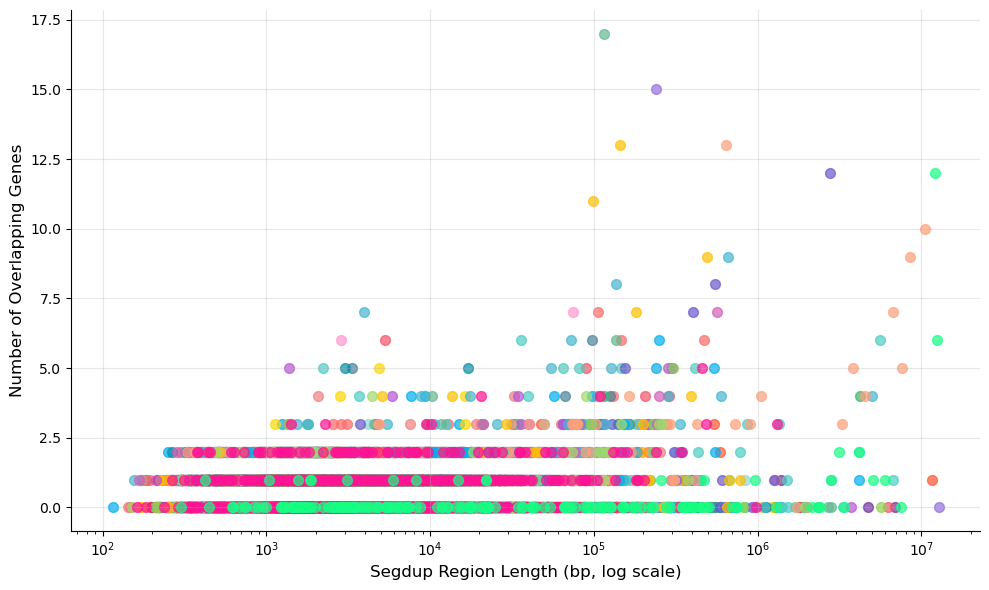

Correlation between length and gene count: 0.152

Statistics:
Average length: 18,037 bp
Average gene count: 0.50
Largest region: 12,756,190 bp with 0 genes
Region with most genes: 17 genes with length 114,828 bp


In [24]:
# Create the scatterplot
plt.figure(figsize=(10, 6))

# Plot each point with chromosome-specific color
for i, row in merged_segdup.iterrows():
    chrom = row['chrom']
    color = chr_colors.get(chrom, '#CCCCCC')  # Default gray if chromosome not in dict
    plt.scatter(row['Length'], row['gene_count'], 
                color=color, alpha=0.7, s=50, label=chrom if i == 0 else "")

plt.xlabel('Segdup Region Length (bp)', fontsize=12)
plt.ylabel('Number of Overlapping Genes', fontsize=12)
plt.grid(True, alpha=0.3)

# Remove spines for publication style
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional: Log scale for x-axis if lengths vary widely
if merged_segdup['Length'].max() / merged_segdup['Length'].min() > 100:
    plt.xscale('log')
    plt.xlabel('Segdup Region Length (bp, log scale)', fontsize=12)

plt.tight_layout()
plt.show()

# Print correlation statistics
correlation = merged_segdup['Length'].corr(merged_segdup['gene_count'])
print(f"Correlation between length and gene count: {correlation:.3f}")

# Show some statistics
print(f"\nStatistics:")
print(f"Average length: {merged_segdup['Length'].mean():,.0f} bp")
print(f"Average gene count: {merged_segdup['gene_count'].mean():.2f}")
print(f"Largest region: {merged_segdup['Length'].max():,} bp with {merged_segdup.loc[merged_segdup['Length'].idxmax(), 'gene_count']} genes")
print(f"Region with most genes: {merged_segdup['gene_count'].max()} genes with length {merged_segdup.loc[merged_segdup['gene_count'].idxmax(), 'Length']:,} bp")

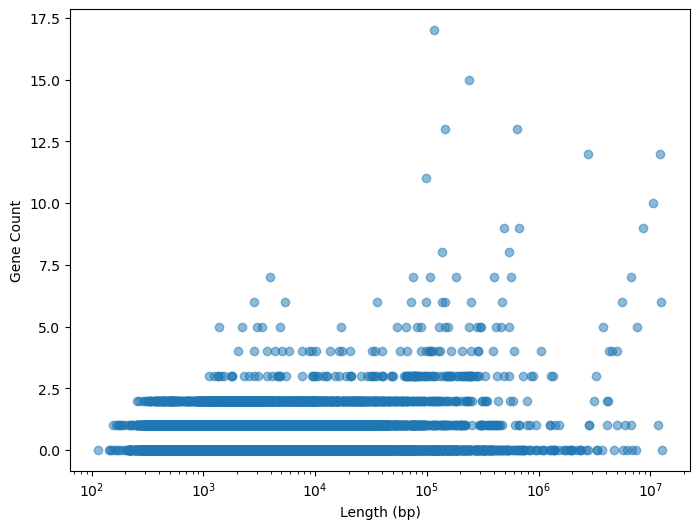

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(merged_segdup['Length'], merged_segdup['gene_count'], alpha=0.5)
plt.xlabel('Length (bp)')
plt.ylabel('Gene Count')
plt.xscale("log")
plt.show()

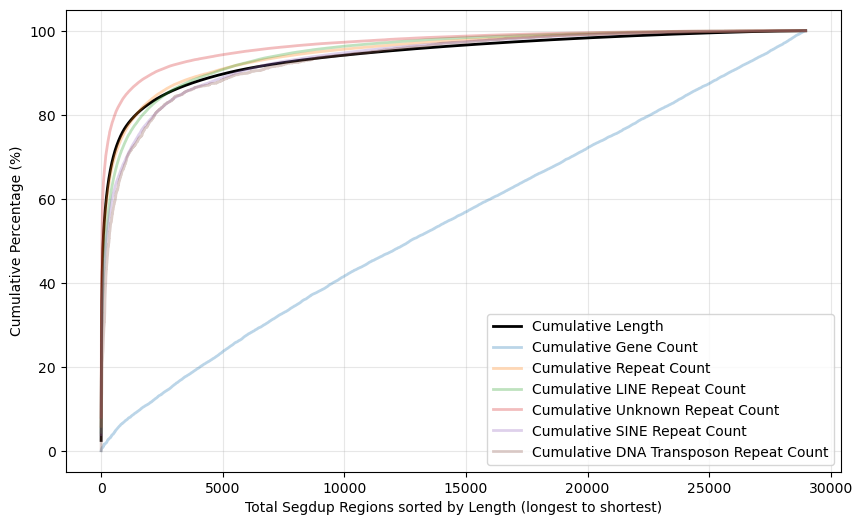

In [55]:
# Sort by Length for cumulative length
sorted_by_length = merged_segdup.sort_values('Length', ascending=False)
sorted_by_length['Cumulative_Length'] = sorted_by_length['Length'].cumsum()
total_length = sorted_by_length['Length'].sum()
sorted_by_length['Cumulative_Length_Pct'] = (sorted_by_length['Cumulative_Length'] / total_length) * 100

# Use the same sorted order for gene count calculations
sorted_by_length['Cumulative_Genes'] = sorted_by_length['gene_count'].cumsum()
total_genes = sorted_by_length['gene_count'].sum()
sorted_by_length['Cumulative_Genes_Pct'] = (sorted_by_length['Cumulative_Genes'] / total_genes) * 100

# Use the same sorted order for repeat count calculations
sorted_by_length['Cumulative_Repeats'] = sorted_by_length['repeat_count'].cumsum()
total_repeats = sorted_by_length['repeat_count'].sum()
sorted_by_length['Cumulative_Repeat_Pct'] = (sorted_by_length['Cumulative_Repeats'] / total_repeats) * 100

# Use the same sorted order for repeat count calculations
sorted_by_length['Cumulative_LINE'] = sorted_by_length['LINE_repeat_count'].cumsum()
total_repeats = sorted_by_length['LINE_repeat_count'].sum()
sorted_by_length['Cumulative_LINE_Pct'] = (sorted_by_length['Cumulative_LINE'] / total_repeats) * 100
# Use the same sorted order for repeat count calculations
sorted_by_length['Cumulative_Unknown'] = sorted_by_length['unknown_repeat_count'].cumsum()
total_repeats = sorted_by_length['unknown_repeat_count'].sum()
sorted_by_length['Cumulative_Unknown_Pct'] = (sorted_by_length['Cumulative_Unknown'] / total_repeats) * 100
# Use the same sorted order for repeat count calculations
sorted_by_length['Cumulative_SINE'] = sorted_by_length['SINE_repeat_count'].cumsum()
total_repeats = sorted_by_length['SINE_repeat_count'].sum()
sorted_by_length['Cumulative_SINE_Pct'] = (sorted_by_length['Cumulative_SINE'] / total_repeats) * 100
# Use the same sorted order for repeat count calculations
sorted_by_length['Cumulative_DNA_transposon'] = sorted_by_length['DNA_transposon_repeat_count'].cumsum()
total_repeats = sorted_by_length['DNA_transposon_repeat_count'].sum()
sorted_by_length['Cumulative_DNA_transposon_Pct'] = (sorted_by_length['Cumulative_DNA_transposon'] / total_repeats) * 100

# Create the plot
plt.figure(figsize=(10, 6))

# Cumulative Length
plt.plot(range(1, len(sorted_by_length) + 1), sorted_by_length['Cumulative_Length_Pct'], 
         label='Cumulative Length', linewidth=2, color="black")

# Cumulative Gene Count
plt.plot(range(1, len(sorted_by_length) + 1), sorted_by_length['Cumulative_Genes_Pct'], 
         label='Cumulative Gene Count', linewidth=2,alpha=0.3)

# Cumulative Repeat Count
plt.plot(range(1, len(sorted_by_length) + 1), sorted_by_length['Cumulative_Repeat_Pct'], 
         label='Cumulative Repeat Count', linewidth=2,alpha=0.3)

# Cumulative Repeat Count
plt.plot(range(1, len(sorted_by_length) + 1), sorted_by_length['Cumulative_LINE_Pct'], 
         label='Cumulative LINE Repeat Count', linewidth=2,alpha=0.3)
# Cumulative Repeat Count
plt.plot(range(1, len(sorted_by_length) + 1), sorted_by_length['Cumulative_Unknown_Pct'], 
         label='Cumulative Unknown Repeat Count', linewidth=2,alpha=0.3)
# Cumulative Repeat Count
plt.plot(range(1, len(sorted_by_length) + 1), sorted_by_length['Cumulative_SINE_Pct'], 
         label='Cumulative SINE Repeat Count', linewidth=2,alpha=0.3)
# Cumulative Repeat Count
plt.plot(range(1, len(sorted_by_length) + 1), sorted_by_length['Cumulative_DNA_transposon_Pct'], 
         label='Cumulative DNA Transposon Repeat Count', linewidth=2,alpha=0.3)

plt.xlabel('Total Segdup Regions sorted by Length (longest to shortest)')
plt.ylabel('Cumulative Percentage (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

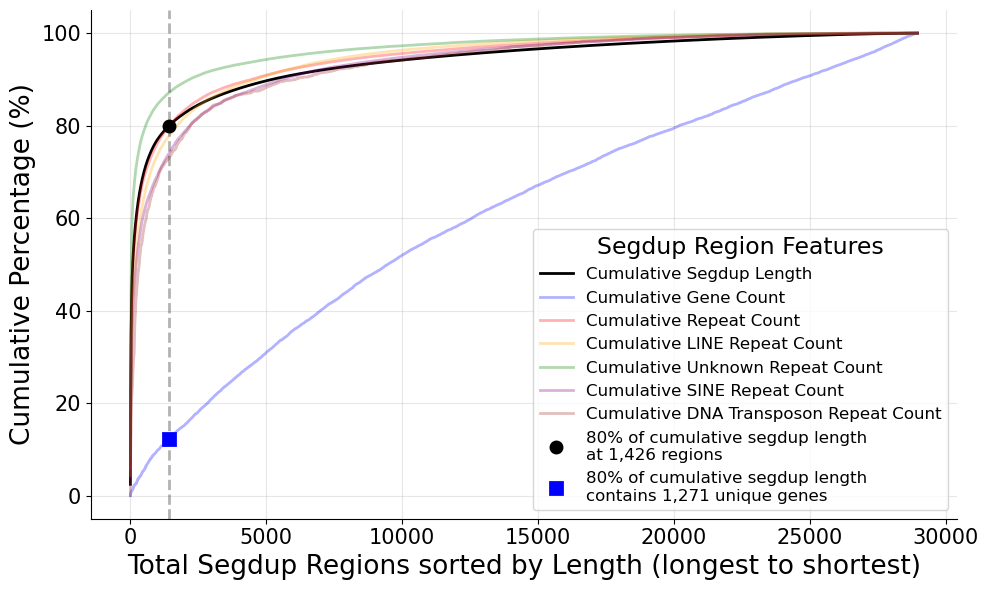

Length 80%: 1,426 regions | Genes at 80% length: 12.2% (1,273 unique genes)


In [84]:
# Paste this entire block into ONE new cell in 05_cumulative_feature_overlap.ipynb.
# SELF-CONTAINED: rebuilds sorted_by_length with ALL cumulative columns, plots
# every curve, draws the 80% cumulative-segdup-LENGTH vertical line (black), and
# adds a gene marker at that SAME x-position (where the length line crosses the
# gene curve), showing the cumulative-gene % and gene count in the legend.
#
# Requires `merged_segdup`, `genes`, `curves`, `np`, `plt`, and `intervaltree` already defined (they are).

# --- Rebuild all cumulative columns (safe to run anytime) ---
sorted_by_length = merged_segdup.sort_values('Length', ascending=False).copy()

sorted_by_length['Cumulative_Length'] = sorted_by_length['Length'].cumsum()
total_length = sorted_by_length['Length'].sum()
sorted_by_length['Cumulative_Length_Pct'] = (sorted_by_length['Cumulative_Length'] / total_length) * 100

# Cumulative UNIQUE gene count (each gene counted once, even if it spans
# multiple merged regions). Walk length-sorted regions accumulating the set of
# distinct genes covered -- a gene is added the first time any region covers it.
_gene_trees = {}
for _chrom, _grp in genes.groupby('Chromosome'):
    _t = intervaltree.IntervalTree()
    for _, _g in _grp.iterrows():
        _t.addi(int(_g['Start']), int(_g['End']), _g['gene'])
    _gene_trees[_chrom] = _t

_covered_genes = set()
_cum_unique = []
for _, _r in sorted_by_length.iterrows():
    _t = _gene_trees.get(_r['chrom'])
    if _t:
        for _iv in _t.overlap(int(_r['start']), int(_r['end'])):
            _covered_genes.add(_iv.data)
    _cum_unique.append(len(_covered_genes))

total_genes = len(_covered_genes)
sorted_by_length['Cumulative_Genes'] = _cum_unique
sorted_by_length['Cumulative_Genes_Pct'] = (np.array(_cum_unique) / total_genes) * 100

sorted_by_length['Cumulative_Repeats'] = sorted_by_length['repeat_count'].cumsum()
total_repeats = sorted_by_length['repeat_count'].sum()
sorted_by_length['Cumulative_Repeat_Pct'] = (sorted_by_length['Cumulative_Repeats'] / total_repeats) * 100

sorted_by_length['Cumulative_LINE'] = sorted_by_length['LINE_repeat_count'].cumsum()
total_repeats = sorted_by_length['LINE_repeat_count'].sum()
sorted_by_length['Cumulative_LINE_Pct'] = (sorted_by_length['Cumulative_LINE'] / total_repeats) * 100

sorted_by_length['Cumulative_Unknown'] = sorted_by_length['unknown_repeat_count'].cumsum()
total_repeats = sorted_by_length['unknown_repeat_count'].sum()
sorted_by_length['Cumulative_Unknown_Pct'] = (sorted_by_length['Cumulative_Unknown'] / total_repeats) * 100

sorted_by_length['Cumulative_SINE'] = sorted_by_length['SINE_repeat_count'].cumsum()
total_repeats = sorted_by_length['SINE_repeat_count'].sum()
sorted_by_length['Cumulative_SINE_Pct'] = (sorted_by_length['Cumulative_SINE'] / total_repeats) * 100

sorted_by_length['Cumulative_DNA_transposon'] = sorted_by_length['DNA_transposon_repeat_count'].cumsum()
total_repeats = sorted_by_length['DNA_transposon_repeat_count'].sum()
sorted_by_length['Cumulative_DNA_transposon_Pct'] = (sorted_by_length['Cumulative_DNA_transposon'] / total_repeats) * 100


# --- Plot with 80% threshold for Length + gene intersection ---
size=17
plt.figure(figsize=(10, 6))

colors = {
    'Length': 'black',
    'Genes': 'blue',
    'All_Repeats': 'red',
    'LINE': 'orange',
    'Unknown': 'green',
    'SINE': 'purple',
    'DNA_transposon': 'brown'
}

# Clear labels that make it explicit these are cumulative curves
label_map = {
    'Length': 'Cumulative Segdup Length',
    'Genes': 'Cumulative Gene Count',
    'All_Repeats': 'Cumulative Repeat Count',
    'LINE': 'Cumulative LINE Repeat Count',
    'Unknown': 'Cumulative Unknown Repeat Count',
    'SINE': 'Cumulative SINE Repeat Count',
    'DNA_transposon': 'Cumulative DNA Transposon Repeat Count',
}

for name, col in curves.items():
    plt.plot(range(1, len(sorted_by_length) + 1), sorted_by_length[col],
             label=label_map[name], linewidth=2,
             alpha=0.3 if name != 'Length' else 1.0,
             color=colors[name])

# --- 80% threshold for cumulative segdup LENGTH (black) ---
y_length = sorted_by_length['Cumulative_Length_Pct'].values
region_80_idx = int(np.argmax(y_length >= 80))
plt.axvline(x=region_80_idx + 1, color='black', linestyle='--', alpha=0.3, linewidth=2)
plt.plot(region_80_idx + 1, 80, 'o', color='black', markersize=8,
         markerfacecolor='black', markeredgecolor='black', markeredgewidth=2,
         label=f'80% of cumulative segdup length\nat {region_80_idx + 1:,} regions')

# --- Gene intersection AT the length-80% line (blue marker on the gene curve) ---
genes_pct_at_80 = float(sorted_by_length['Cumulative_Genes_Pct'].iloc[region_80_idx])
n_genes_at_80 = int(sorted_by_length['Cumulative_Genes'].iloc[region_80_idx])
plt.plot(region_80_idx + 1, genes_pct_at_80, 's', color='blue', markersize=9,
         markerfacecolor='blue', markeredgecolor='blue', markeredgewidth=2,
         label=f'80% of cumulative segdup length\ncontains {n_genes_at_80 -2:,} unique genes')

plt.xlabel('Total Segdup Regions sorted by Length (longest to shortest)', fontsize=size+2)
plt.ylabel('Cumulative Percentage (%)', fontsize=size+2)
plt.yticks(fontsize=size-2)
plt.xticks(fontsize=size-2)
plt.legend(title="Segdup Region Features", title_fontsize=size,
           loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("cumulative_segdup_80pct.png",dpi=300,bbox_inches="tight")
plt.show()
print(f"Length 80%: {region_80_idx + 1:,} regions | "
      f"Genes at 80% length: {genes_pct_at_80:.1f}% ({n_genes_at_80:,} unique genes)")


In [56]:
curves={'Length': 'Cumulative_Length_Pct',
 'Genes': 'Cumulative_Genes_Pct',
 'All_Repeats': 'Cumulative_Repeat_Pct',
 'LINE': 'Cumulative_LINE_Pct',
 'Unknown': 'Cumulative_Unknown_Pct',
 'SINE': 'Cumulative_SINE_Pct',
 'DNA_transposon': 'Cumulative_DNA_transposon_Pct'}
curves

{'Length': 'Cumulative_Length_Pct',
 'Genes': 'Cumulative_Genes_Pct',
 'All_Repeats': 'Cumulative_Repeat_Pct',
 'LINE': 'Cumulative_LINE_Pct',
 'Unknown': 'Cumulative_Unknown_Pct',
 'SINE': 'Cumulative_SINE_Pct',
 'DNA_transposon': 'Cumulative_DNA_transposon_Pct'}

In [57]:
# Analyze slopes for all cumulative curves
slope_analysis = {}

for name, col in curves.items():
    y = sorted_by_length[col].values
    slopes = np.diff(y)
    
    # Find where slope is closest to 1
    slope_differences = np.abs(slopes - 1.0)
    min_slope_idx = np.argmin(slope_differences)
    
    slope_1_region = min_slope_idx + 1
    slope_1_percentage = y[slope_1_region]
    slope_1_actual_slope = slopes[min_slope_idx]
    
    slope_analysis[name] = {
        'region': slope_1_region,
        'percentage': slope_1_percentage,
        'actual_slope': slope_1_actual_slope,
        'regions_percentage': (slope_1_region / len(sorted_by_length)) * 100
    }

# Print slope analysis
print("SLOPE = 1.0 ANALYSIS")
print("="*80)
print(f"{'Feature':<20} {'Region':<10} {'Cumulative %':<15} {'Actual Slope':<15} {'% of Regions':<15}")
print("-"*80)

for name, data in slope_analysis.items():
    print(f"{name:<20} {data['region']:<10,} {data['percentage']:<15.2f} {data['actual_slope']:<15.3f} {data['regions_percentage']:<15.1f}")

SLOPE = 1.0 ANALYSIS
Feature              Region     Cumulative %    Actual Slope    % of Regions   
--------------------------------------------------------------------------------
Length               15         25.30           0.970           0.1            
Genes                512        4.14            0.118           1.8            
All_Repeats          3          11.71           0.991           0.0            
LINE                 14         21.10           1.071           0.0            
Unknown              20         41.54           0.994           0.1            
SINE                 16         22.03           0.939           0.1            
DNA_transposon       40         20.34           0.974           0.1            


In [58]:
# Paste this into a NEW cell in 05_cumulative_feature_overlap.ipynb,
# placed right AFTER the slope-analysis cell (the one ending with
#   print("SLOPE = 1.0 ANALYSIS")
# ), i.e. just BEFORE the stray `region_80_idx` cell.
#
# It rebuilds the cumulative-length columns cleanly and defines the
# 80%-threshold variables correctly.

# --- Rebuild cumulative-length columns (safe to run anytime, restores a clean sorted_by_length) ---
sorted_by_length = merged_segdup.sort_values('Length', ascending=False).copy()
sorted_by_length['Cumulative_Length'] = sorted_by_length['Length'].cumsum()
total_length = sorted_by_length['Length'].sum()
sorted_by_length['Cumulative_Length_Pct'] = (sorted_by_length['Cumulative_Length'] / total_length) * 100

# --- 80% threshold (cumulative length only) ---
y_length = sorted_by_length['Cumulative_Length_Pct'].values
region_80_idx = int(np.argmax(y_length >= 80))           # 0-based index of first region that reaches 80%
correct_80_region = region_80_idx + 1                    # number of regions (1-based count)
correct_80_percentage = float(y_length[region_80_idx])   # actual cumulative % at that region

print(f"Correct 80% threshold: {correct_80_region:,} regions contain {correct_80_percentage:.2f}% of total length")


# ---------------------------------------------------------------------------
# Optional: replace the plot cell's final print(...) line with this corrected
# version (the current one uses {region_80_idx:,}, which is 0-based / off by
# one as a region COUNT):
# ---------------------------------------------------------------------------
print(f"Correct 80% threshold: {correct_80_region:,} regions contain {correct_80_percentage:.2f}% of total length")


# ---------------------------------------------------------------------------
# Then DELETE these leftover cells, which cause the breakage:
#   * the three stray cells containing only:
#         region_80_idx
#         y_length[region_80_idx]
#         correct_80_percentage = region_80_idx
#   * the late duplicate cell that re-runs
#         sorted_by_length = merged_segdup.sort_values('Length', ascending=False)
#     and computes only `Cumulative_Length` (NOT the _Pct column) — this one
#     wipes `Cumulative_Length_Pct` and causes the KeyError in the
#     segdup_hotspots cell.
# ---------------------------------------------------------------------------


Correct 80% threshold: 1,426 regions contain 80.00% of total length
Correct 80% threshold: 1,426 regions contain 80.00% of total length


In [60]:
segdup_hotspots = sorted_by_length[sorted_by_length["Cumulative_Length_Pct"]<=80]
segdup_hotspots = segdup_hotspots.rename(columns={'chrom': 'Chromosome'})
segdup_hotspots = segdup_hotspots.rename(columns={'start': 'Start'})
segdup_hotspots = segdup_hotspots.rename(columns={'end': 'End'})

segdup_hotspots.to_csv("segdup_hotspots_80percLength.tsv",sep="\t")

In [66]:
# Paste into a NEW cell (or run as a standalone script) to generate
#   segdup_genes_hotspots_80percLength.tsv
#
# This is the GENE-LEVEL table (genes inside the 80% pervasive hotspots),
# which is the `go_df` input for step 6 (06_go_enrichment.ipynb).
#
# It is NOT the same as segdup_hotspots_80percLength.tsv (region-level table
# that step 5 already writes).
#
# Requires these two upstream outputs to already exist:
#   * segdup_hotspots_80percLength.tsv          <- from 05 notebook (step 5)
#   * hifiasm_gene_segDup_overlapInfo_081726.tsv <- from 04 notebook (step 4)

import numpy as np
import pandas as pd
from intervaltree import IntervalTree

# --- Inputs (outputs of steps 4 and 5) ---
HOTSPOT_TSV = "segdup_hotspots_80percLength.tsv"                  # region-level 80% hotspots (step 5)
GENES_TSV   = "hifiasm_gene_segDup_overlapInfo_081726.tsv"       # all genes + overlap flag (step 4)
OUT_TSV     = "segdup_genes_hotspots_80percLength.tsv"

# --- 1. Load 80% hotspot regions (Chromosome / Start / End) ---
hotspots = pd.read_csv(HOTSPOT_TSV, sep="\t")

# --- 2. Load genes (0-based half-open Start/End) ---
genes = pd.read_csv(GENES_TSV, sep="\t")
genes["Start"] = genes["Start"].astype(int)
genes["End"]   = genes["End"].astype(int)

# --- 3. Build per-chromosome interval tree over the hotspot regions ---
trees = {}
for chrom, grp in hotspots.groupby("Chromosome"):
    trees[chrom] = IntervalTree.from_tuples(
        zip(grp["Start"].astype(int), grp["End"].astype(int), range(len(grp)))
    )

# --- 4. Keep genes whose interval overlaps a hotspot region ---
def overlaps_hotspot(row):
    tree = trees.get(row["Chromosome"])
    return bool(tree.overlaps(row["Start"], row["End"])) if tree is not None else False

result_df = genes[genes.apply(overlaps_hotspot, axis=1)].copy()

# --- 5. Write (default index=True, matching step 6's index_col=0 read) ---
result_df.to_csv(OUT_TSV, sep="\t")
print(f"{len(result_df):,} genes overlap the 80% hotspots -> {OUT_TSV}")
print(result_df["gene"].nunique(), "unique gene names")


1,271 genes overlap the 80% hotspots -> segdup_genes_hotspots_80percLength.tsv
1271 unique gene names


In [61]:
print("This is how long the segdup regionsare are:")
sorted_by_length["Length"].sum()

This is how long the segdup regionsare are:


np.int64(522366686)

In [62]:
print("This is how long the segdup hotspots are:")
segdup_hotspots["Length"].sum()

This is how long the segdup hotspots are:


np.int64(417866785)

In [63]:
print(sorted_by_length[sorted_by_length["Cumulative_Length_Pct"]<=80]["Cumulative_Length_Pct"])

16980     2.441999
28780     4.843110
28813     7.174156
3605      9.411455
20774    11.423746
           ...    
7056     79.971655
12746    79.977472
10143    79.983287
17400    79.989101
5425     79.994915
Name: Cumulative_Length_Pct, Length: 1425, dtype: float64


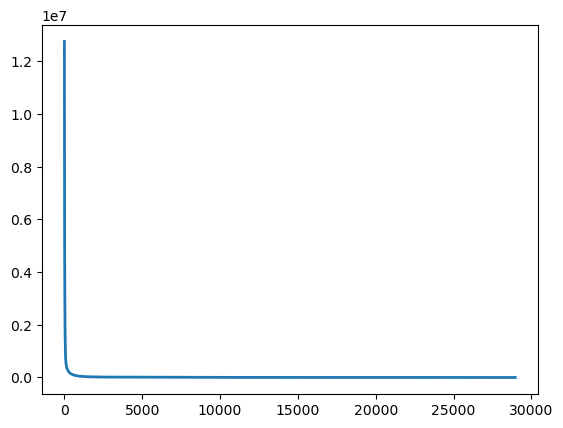

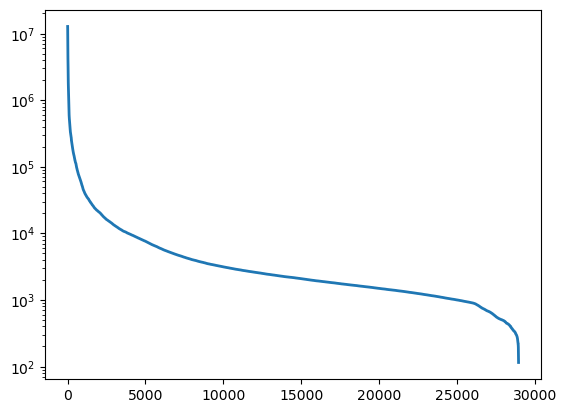

In [64]:
# Cumulative Length
plt.plot(range(1, len(sorted_by_length) + 1), sorted_by_length['Length'], 
         label='Cumulative Length', linewidth=2, )
plt.show()
# plt.yscale("log")

# Cumulative Length
plt.plot(range(1, len(sorted_by_length) + 1), sorted_by_length['Length'], 
         label='Cumulative Length', linewidth=2, )
plt.yscale("log")
plt.show()

NameError: name 'repeat_types' is not defined

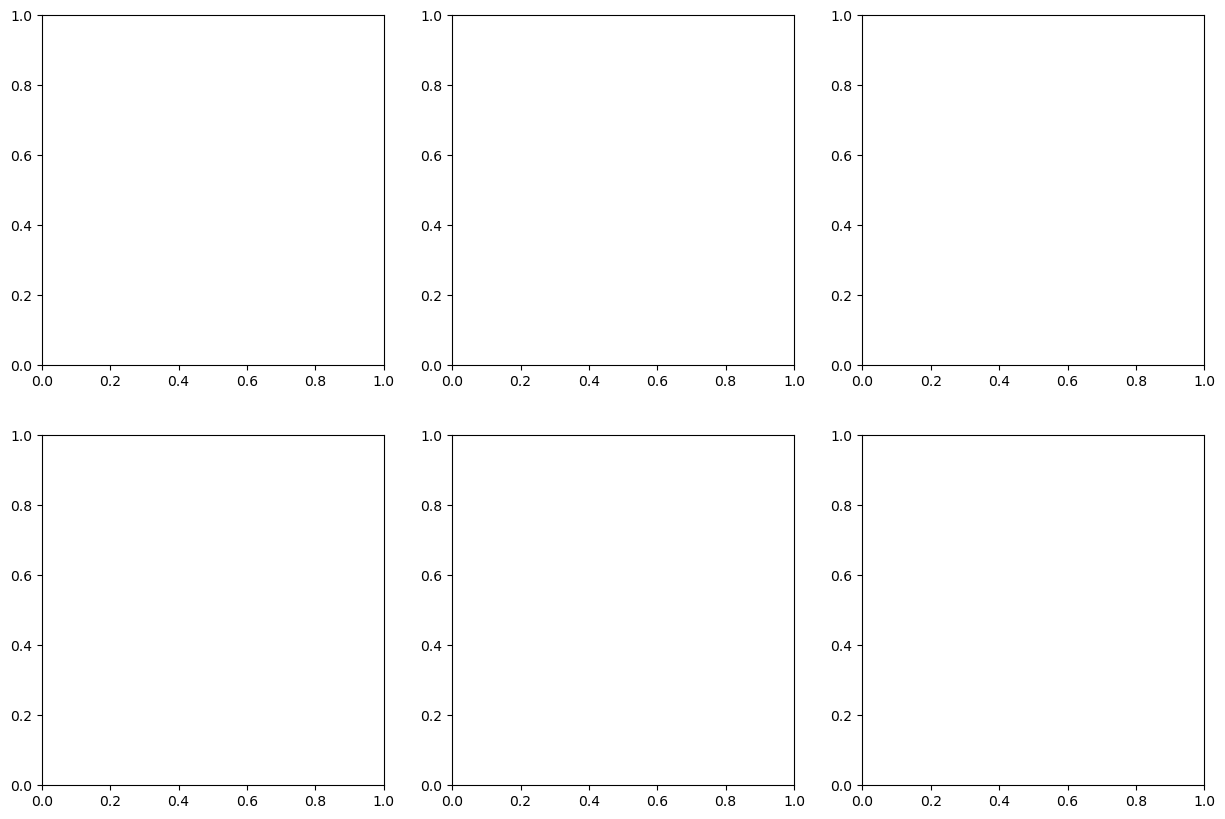

In [65]:
# Create scatter plots with trend lines
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, (col_name, title) in enumerate(repeat_types):
    if i < len(axes):
        # Scatter plot
        scatter = axes[i].scatter(merged_segdup['Length'], merged_segdup[col_name], 
                                 alpha=0.5, s=10, c=merged_segdup[col_name], cmap='viridis')
        
        # # Add trend line
        # if len(merged_segdup) > 1:
        #     # z = np.polyfit(merged_segdup['Length'], merged_segdup[col_name], 1)
        #     # p = np.poly1d(z)
        #     axes[i].plot(merged_segdup['Length'], p(merged_segdup['Length']), 
        #                 "r--", alpha=0.8, linewidth=2)
        
        axes[i].set_xlabel('Segdup Length (bp)')
        axes[i].set_ylabel(f'Number of {title}')
        axes[i].set_title(f'{title} vs Segdup Length\nCorrelation: {merged_segdup["Length"].corr(merged_segdup[col_name]):.3f}')
        
        # Use log scale if data spans large range
        if merged_segdup['Length'].max() / merged_segdup['Length'].min() > 100:
            axes[i].set_xscale('log')
            axes[i].set_xlabel('Segdup Length (bp, log scale)')

plt.tight_layout()
plt.show()

In [36]:
merged_segdup["gene_count"].value_counts()

gene_count
0     16459
1     11087
2      1204
3       120
4        38
5        22
6        11
7         7
9         3
8         2
13        2
12        2
15        1
17        1
10        1
11        1
Name: count, dtype: int64

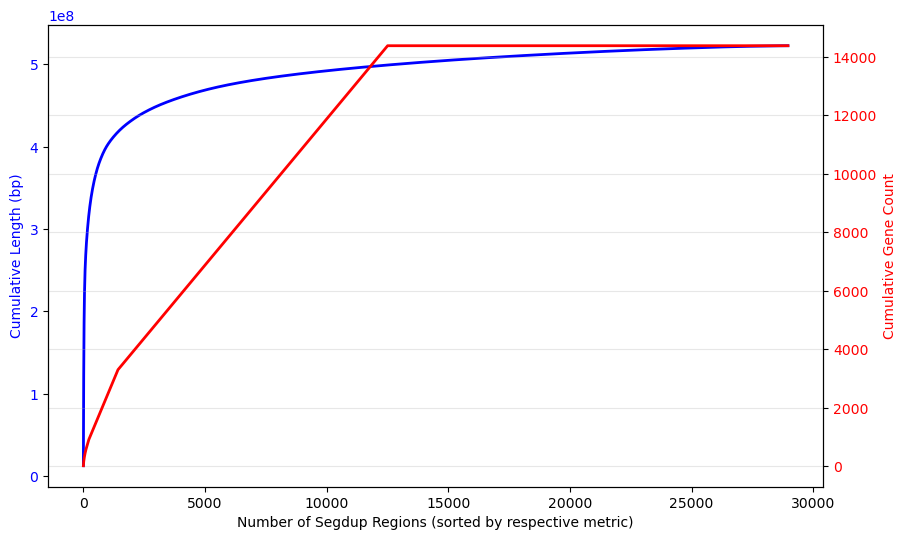

In [37]:
# Sort by Length for cumulative length
sorted_by_length = merged_segdup.sort_values('Length', ascending=False)
sorted_by_length['Cumulative_Length'] = sorted_by_length['Length'].cumsum()
total_length = sorted_by_length['Length'].sum()

# Sort by Gene Count for cumulative gene count  
sorted_by_genes = merged_segdup.sort_values('gene_count', ascending=False)
sorted_by_genes['Cumulative_Genes'] = sorted_by_genes['gene_count'].cumsum()
total_genes = sorted_by_genes['gene_count'].sum()

# Create the plot with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Cumulative Length on left y-axis
ax1.plot(range(1, len(sorted_by_length) + 1), sorted_by_length['Cumulative_Length'], 
         color='blue', label='Cumulative Length', linewidth=2)
ax1.set_xlabel('Number of Segdup Regions (sorted by respective metric)')
ax1.set_ylabel('Cumulative Length (bp)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Cumulative Gene Count on right y-axis
ax2 = ax1.twinx()
ax2.plot(range(1, len(sorted_by_genes) + 1), sorted_by_genes['Cumulative_Genes'], 
         color='red', label='Cumulative Gene Count', linewidth=2)
ax2.set_ylabel('Cumulative Gene Count', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.grid(True, alpha=0.3)
plt.show()